# Training NOTEBOOK

Realiza o treinamento de cada conjunto Arquitetura-Dataset, e salva os pesos do modelo treinado em um arquivo .pth.

In [9]:
import torch
from monai.data import Dataset, DataLoader 
from monai.networks.nets import UNet, AttentionUnet, UNETR
from monai.transforms import Compose, LoadImaged, ScaleIntensityd, RandFlipd, ToTensord, Activations, AsDiscrete, EnsureChannelFirstd
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
import pandas as pd
import os
from pathlib import Path
import random
random.seed(42)
from matplotlib import pyplot as plt

Abaixo estão definidas funções para organizar os dados de entrada do MONAI

In [3]:
CWD = Path(os.getcwd()).parent
print(CWD)

def prepare_splits(labels_csv_path):
    labels_df = pd.read_csv(labels_csv_path)
    train_df = labels_df[labels_df['split'] == 'train']
    val_df = labels_df[labels_df['split'] == 'val']
    test_df = labels_df[labels_df['split'] == 'test']
    return train_df, val_df, test_df

def get_dataset_paths(dataset_name):
    CWD = Path(os.getcwd()).parent
    valid_datasets = ['NuInSeg', 'PanNuke', 'MoNuSeg']
    if dataset_name not in valid_datasets:
        raise ValueError(f"Invalid dataset name: {dataset_name}. Valid options are: {valid_datasets}")
    image_path = Path(CWD / f'data/processed/{dataset_name}/Images/')
    mask_path = Path(CWD / f'data/processed/{dataset_name}/Masks/')
    return image_path, mask_path

def prepare_datasets(df, dataset_name):
    image_path, mask_path = get_dataset_paths(dataset_name)
    print(image_path)
    images = [str(image_path / f"{row['FileName']}.npy") for _, row in df.iterrows()]
    masks = [str(mask_path / f"{row['FileName']}.npy") for _, row in df.iterrows()]
    monai_dict = [{'image': image, 'label': mask} for image, mask in zip(images, masks)]
    return monai_dict

/home/vinicius/IA901/IA901-2026S1/projetos/segmentacao_de_nucleos


Learning rates encontradas no notebook 01_Hyperparameters_Tuning

In [4]:
Lr_otimizadas = {
    "unet": {
        "MoNuSeg": 0.0008609504282625847,
        "PanNuke": 0.0004776163691151915,
        "NuInSeg": 0.00082587306649585
    },
    "attentionunet": {
        "MoNuSeg": 0.0007211141455333722,
        "PanNuke": 0.0004654422789035183,
        "NuInSeg": 0.0007441284120806255},
    "unetr": {
        "MoNuSeg": 0.0002442285941341703,
        "PanNuke": 0.00012597703134079882,
        "NuInSeg": 0.00011902255710902422
    }
}

# Configurando os Datasets

In [6]:
MoNuSeg_csv = CWD / 'data/processed/MoNuSeg/labels.csv'
PanNuke_csv = CWD / 'data/processed/PanNuke/labels.csv'
NuInSeg_csv = CWD / 'data/processed/NuInSeg/labels.csv'

MoNuSeg_train_df, MoNuSeg_val_df, MoNuSeg_test_df = prepare_splits(MoNuSeg_csv)
PanNuke_train_df, PanNuke_val_df, PanNuke_test_df = prepare_splits(PanNuke_csv)
NuInSeg_train_df, NuInSeg_val_df, NuInSeg_test_df = prepare_splits(NuInSeg_csv)

MoNuSeg_train_data = prepare_datasets(MoNuSeg_train_df, 'MoNuSeg')
PanNuke_train_data = prepare_datasets(PanNuke_train_df, 'PanNuke')
NuInSeg_train_data = prepare_datasets(NuInSeg_train_df, 'NuInSeg')

MoNuSeg_val_data = prepare_datasets(MoNuSeg_val_df, 'MoNuSeg')
PanNuke_val_data = prepare_datasets(PanNuke_val_df, 'PanNuke')
NuInSeg_val_data = prepare_datasets(NuInSeg_val_df, 'NuInSeg')


transforms_train = Compose([
    LoadImaged(keys=['image', 'label'], reader="NumpyReader"),

    EnsureChannelFirstd(keys=['image'], channel_dim=-1),
    EnsureChannelFirstd(keys=['label'], channel_dim="no_channel"),

    ScaleIntensityd(keys=['image']),
    RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=0),
    RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=1),
    ToTensord(keys=['image', 'label'])
    ])

transforms_val = Compose([
    LoadImaged(keys=['image', 'label'], reader="NumpyReader"),
    EnsureChannelFirstd(keys=['image'], channel_dim=-1),
    EnsureChannelFirstd(keys=['label'], channel_dim="no_channel"),
    ScaleIntensityd(keys=['image']),
    ToTensord(keys=['image', 'label'])
    ])


MoNuSeg_train_ds = Dataset(data=MoNuSeg_train_data, transform=transforms_train)
PanNuke_train_ds = Dataset(data=PanNuke_train_data, transform=transforms_train)
NuInSeg_train_ds = Dataset(data=NuInSeg_train_data, transform=transforms_train)

MoNuSeg_val_ds = Dataset(data=MoNuSeg_val_data, transform=transforms_val)
PanNuke_val_ds = Dataset(data=PanNuke_val_data, transform=transforms_val)
NuInSeg_val_ds = Dataset(data=NuInSeg_val_data, transform=transforms_val)

datasets = {
    'MoNuSeg': {
        'train': MoNuSeg_train_ds,
        'val': MoNuSeg_val_ds
    },
    'PanNuke': {
        'train': PanNuke_train_ds,
        'val': PanNuke_val_ds
    },
    'NuInSeg': {    
        'train': NuInSeg_train_ds,
        'val': NuInSeg_val_ds
        }
}        


/home/vinicius/IA901/IA901-2026S1/projetos/segmentacao_de_nucleos/data/processed/MoNuSeg/Images
/home/vinicius/IA901/IA901-2026S1/projetos/segmentacao_de_nucleos/data/processed/PanNuke/Images
/home/vinicius/IA901/IA901-2026S1/projetos/segmentacao_de_nucleos/data/processed/NuInSeg/Images
/home/vinicius/IA901/IA901-2026S1/projetos/segmentacao_de_nucleos/data/processed/MoNuSeg/Images
/home/vinicius/IA901/IA901-2026S1/projetos/segmentacao_de_nucleos/data/processed/PanNuke/Images
/home/vinicius/IA901/IA901-2026S1/projetos/segmentacao_de_nucleos/data/processed/NuInSeg/Images


# Treinando UNET

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for dataset_name, dataset_splits in datasets.items():
    print(f"\nIniciando treinamento para o dataset: {dataset_name}")
    
    train_loader = DataLoader(dataset_splits['train'], batch_size=16, shuffle=True)
    val_loader = DataLoader(dataset_splits['val'], batch_size=16, shuffle=False)

    unet = UNet( # unet do monai
        spatial_dims=2,
        in_channels=3,
        out_channels=1,
        channels=(16, 32, 64, 128, 256),
        strides=(2, 2, 2, 2),
        num_res_units=2,
    ).to(device)

    model = unet

    loss_function = DiceCELoss(sigmoid=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=Lr_otimizadas[model.__class__.__name__.lower()][dataset_name])
    dice_metric = DiceMetric(include_background=True, reduction="mean")

    post_pred = Compose([Activations(keys="pred", sigmoid=True), AsDiscrete(keys="pred", threshold=0.5)])
    post_label = Compose([AsDiscrete(threshold=0.5)])

    max_epochs = 50
    val_interval = 1 
    best_metric = -1
    best_metric_epoch = -1

    for epoch in range(max_epochs):
        print("-" * 10)
        print(f"Época {epoch + 1}/{max_epochs}")
        
        # --- FASE DE TREINO ---
        model.train()
        epoch_loss = 0
        step = 0
        
        for batch_data in train_loader:
            step += 1
            inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            
            # Calcula a Loss combinada (Dice + Cross Entropy)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
        epoch_loss /= step
        print(f"Loss média de Treino: {epoch_loss:.4f}")

        # --- FASE DE VALIDAÇÃO ---
        if (epoch + 1) % val_interval == 0:
            model.eval()
            with torch.no_grad():
                for val_data in val_loader:
                    val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)
                    
                    # Predição do modelo
                    val_outputs = model(val_inputs)
                    
                    # Aplica o pós-processamento (limiar de 0.5)
                    val_outputs = [post_pred(i) for i in val_outputs]
                    val_labels = [post_label(i) for i in val_labels]
                    
                    # Computa a métrica Dice para o batch atual
                    dice_metric(y_pred=val_outputs, y=val_labels)
                
                # Agrega o resultado de toda a validação
                metric = dice_metric.aggregate().item()
                dice_metric.reset() # Reseta para a próxima validação
                
                print(f"Métrica Dice na Validação: {metric:.4f}")
                
                # Salva o melhor modelo baseado no Score Dice
                if metric > best_metric:
                    best_metric = metric
                    best_metric_epoch = epoch + 1
                    torch.save(model.state_dict(), f"results/models/{model.__class__.__name__.lower()}/{dataset_name}_{model.__class__.__name__}.pth")
                    print("Encontrado um novo melhor modelo! Salvo com sucesso.")
    print(f"\nTreino concluído! Melhor Dice: {best_metric:.4f} na época {best_metric_epoch}")
                    




Iniciando treinamento para o dataset: MoNuSeg
----------
Época 1/50


Can't initialize NVML


Loss média de Treino: 1.2737
Métrica Dice na Validação: 0.5098
Encontrado um novo melhor modelo! Salvo com sucesso.
----------
Época 2/50
Loss média de Treino: 1.1780
Métrica Dice na Validação: 0.5573
Encontrado um novo melhor modelo! Salvo com sucesso.
----------
Época 3/50
Loss média de Treino: 1.1568
Métrica Dice na Validação: 0.6106
Encontrado um novo melhor modelo! Salvo com sucesso.
----------
Época 4/50
Loss média de Treino: 1.1344
Métrica Dice na Validação: 0.6521
Encontrado um novo melhor modelo! Salvo com sucesso.
----------
Época 5/50
Loss média de Treino: 1.1159
Métrica Dice na Validação: 0.6802
Encontrado um novo melhor modelo! Salvo com sucesso.
----------
Época 6/50
Loss média de Treino: 1.0977
Métrica Dice na Validação: 0.7033
Encontrado um novo melhor modelo! Salvo com sucesso.
----------
Época 7/50
Loss média de Treino: 1.0760
Métrica Dice na Validação: 0.7212
Encontrado um novo melhor modelo! Salvo com sucesso.
----------
Época 8/50
Loss média de Treino: 1.0521
Métri

# Treinando AttentionUnet

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for dataset_name, dataset_splits in datasets.items():
    print(f"\nIniciando treinamento para o dataset: {dataset_name}")
    
    train_loader = DataLoader(dataset_splits['train'], batch_size=16, shuffle=True)
    val_loader = DataLoader(dataset_splits['val'], batch_size=16, shuffle=False)

    attention_unet = AttentionUnet( # attention unet do monai
        spatial_dims=2,
        in_channels=3,
        out_channels=1,
        channels=(16, 32, 64, 128, 256),
        strides=(2, 2, 2, 2)
    ).to(device)

    model = attention_unet

    loss_function = DiceCELoss(sigmoid=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=Lr_otimizadas[model.__class__.__name__.lower()][dataset_name])
    dice_metric = DiceMetric(include_background=True, reduction="mean")

    post_pred = Compose([Activations(keys="pred", sigmoid=True), AsDiscrete(keys="pred", threshold=0.5)])
    post_label = Compose([AsDiscrete(threshold=0.5)])

    max_epochs = 50
    val_interval = 1 
    best_metric = -1
    best_metric_epoch = -1

    for epoch in range(max_epochs):
        print("-" * 10)
        print(f"Época {epoch + 1}/{max_epochs}")
        
        # --- FASE DE TREINO ---
        model.train()
        epoch_loss = 0
        step = 0
        
        for batch_data in train_loader:
            step += 1
            inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            
            # Calcula a Loss combinada (Dice + Cross Entropy)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
        epoch_loss /= step
        print(f"Loss média de Treino: {epoch_loss:.4f}")

        # --- FASE DE VALIDAÇÃO ---
        if (epoch + 1) % val_interval == 0:
            model.eval()
            with torch.no_grad():
                for val_data in val_loader:
                    val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)
                    
                    # Predição do modelo
                    val_outputs = model(val_inputs)
                    
                    # Aplica o pós-processamento (limiar de 0.5)
                    val_outputs = [post_pred(i) for i in val_outputs]
                    val_labels = [post_label(i) for i in val_labels]
                    
                    # Computa a métrica Dice para o batch atual
                    dice_metric(y_pred=val_outputs, y=val_labels)
                
                # Agrega o resultado de toda a validação
                metric = dice_metric.aggregate().item()
                dice_metric.reset() # Reseta para a próxima validação
                
                print(f"Métrica Dice na Validação: {metric:.4f}")
                
                # Salva o melhor modelo baseado no Score Dice
                if metric > best_metric:
                    best_metric = metric
                    best_metric_epoch = epoch + 1
                    torch.save(model.state_dict(), f"results/models/{model.__class__.__name__.lower()}/{dataset_name}_{model.__class__.__name__}.pth")
                    print("Encontrado um novo melhor modelo! Salvo com sucesso.")
    print(f"\nTreino concluído! Melhor Dice: {best_metric:.4f} na época {best_metric_epoch}")
                    




Iniciando treinamento para o dataset: MoNuSeg
----------
Época 1/50
Loss média de Treino: 0.9596
Métrica Dice na Validação: 0.3881
Encontrado um novo melhor modelo! Salvo com sucesso.
----------
Época 2/50
Loss média de Treino: 0.7986
Métrica Dice na Validação: 0.6384
Encontrado um novo melhor modelo! Salvo com sucesso.
----------
Época 3/50
Loss média de Treino: 0.7645
Métrica Dice na Validação: 0.7617
Encontrado um novo melhor modelo! Salvo com sucesso.
----------
Época 4/50
Loss média de Treino: 0.7331
Métrica Dice na Validação: 0.7754
Encontrado um novo melhor modelo! Salvo com sucesso.
----------
Época 5/50
Loss média de Treino: 0.7097
Métrica Dice na Validação: 0.7915
Encontrado um novo melhor modelo! Salvo com sucesso.
----------
Época 6/50
Loss média de Treino: 0.6962
Métrica Dice na Validação: 0.7852
----------
Época 7/50
Loss média de Treino: 0.6786
Métrica Dice na Validação: 0.7811
----------
Época 8/50
Loss média de Treino: 0.6564
Métrica Dice na Validação: 0.7987
Encontra

# Treinando UNETR

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for dataset_name, dataset_splits in datasets.items():
    print(f"\nIniciando treinamento para o dataset: {dataset_name}")
    
    train_loader = DataLoader(dataset_splits['train'], batch_size=16, shuffle=True)
    val_loader = DataLoader(dataset_splits['val'], batch_size=16, shuffle=False)

    unetr = UNETR( # unetr do monai
        in_channels=3,
        out_channels=1,
        img_size=(256, 256),
        spatial_dims=2
    ).to(device)


    model = unetr

    loss_function = DiceCELoss(sigmoid=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=Lr_otimizadas[model.__class__.__name__.lower()][dataset_name])
    dice_metric = DiceMetric(include_background=True, reduction="mean")

    post_pred = Compose([Activations(keys="pred", sigmoid=True), AsDiscrete(keys="pred", threshold=0.5)])
    post_label = Compose([AsDiscrete(threshold=0.5)])

    max_epochs = 50
    val_interval = 1 
    best_metric = -1
    best_metric_epoch = -1

    for epoch in range(max_epochs):
        print("-" * 10)
        print(f"Época {epoch + 1}/{max_epochs}")
        
        # --- FASE DE TREINO ---
        model.train()
        epoch_loss = 0
        step = 0
        
        for batch_data in train_loader:
            step += 1
            inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            
            # Calcula a Loss combinada (Dice + Cross Entropy)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
        epoch_loss /= step
        print(f"Loss média de Treino: {epoch_loss:.4f}")

        # --- FASE DE VALIDAÇÃO ---
        if (epoch + 1) % val_interval == 0:
            model.eval()
            with torch.no_grad():
                for val_data in val_loader:
                    val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)
                    
                    # Predição do modelo
                    val_outputs = model(val_inputs)
                    
                    # Aplica o pós-processamento (limiar de 0.5)
                    val_outputs = [post_pred(i) for i in val_outputs]
                    val_labels = [post_label(i) for i in val_labels]
                    
                    # Computa a métrica Dice para o batch atual
                    dice_metric(y_pred=val_outputs, y=val_labels)
                
                # Agrega o resultado de toda a validação
                metric = dice_metric.aggregate().item()
                dice_metric.reset() # Reseta para a próxima validação
                
                print(f"Métrica Dice na Validação: {metric:.4f}")
                
                # Salva o melhor modelo baseado no Score Dice
                if metric > best_metric:
                    best_metric = metric
                    best_metric_epoch = epoch + 1
                    torch.save(model.state_dict(), f"results/models/{model.__class__.__name__.lower()}/{dataset_name}_{model.__class__.__name__}.pth")
                    print("Encontrado um novo melhor modelo! Salvo com sucesso.")
    print(f"\nTreino concluído! Melhor Dice: {best_metric:.4f} na época {best_metric_epoch}")
                    




Iniciando treinamento para o dataset: MoNuSeg
----------
Época 1/50
Loss média de Treino: 1.3212
Métrica Dice na Validação: 0.5614
Encontrado um novo melhor modelo! Salvo com sucesso.
----------
Época 2/50
Loss média de Treino: 1.1519
Métrica Dice na Validação: 0.6609
Encontrado um novo melhor modelo! Salvo com sucesso.
----------
Época 3/50
Loss média de Treino: 1.0945
Métrica Dice na Validação: 0.6966
Encontrado um novo melhor modelo! Salvo com sucesso.
----------
Época 4/50
Loss média de Treino: 1.0647
Métrica Dice na Validação: 0.7093
Encontrado um novo melhor modelo! Salvo com sucesso.
----------
Época 5/50
Loss média de Treino: 1.0459
Métrica Dice na Validação: 0.7181
Encontrado um novo melhor modelo! Salvo com sucesso.
----------
Época 6/50
Loss média de Treino: 1.0330
Métrica Dice na Validação: 0.7239
Encontrado um novo melhor modelo! Salvo com sucesso.
----------
Época 7/50
Loss média de Treino: 1.0176
Métrica Dice na Validação: 0.7319
Encontrado um novo melhor modelo! Salvo 

# Few-Shot (Adaptação de Domínio)

Ajuste fino de um modelo pré-treinado usando apenas `K_shots` amostras do MoNuSeg (domínio alvo). Inspirado em *"Few-Shot Learning for Annotation-Efficient Nucleus Instance Segmentation"*.

Support set: 5 amostras do NuInSeg.

── Few-Shot: unet ──
Época 1/20 — Loss: 0.6384
  → Melhor modelo salvo (Loss: 0.6384)
Época 2/20 — Loss: 0.6105
  → Melhor modelo salvo (Loss: 0.6105)
Época 3/20 — Loss: 0.6085
  → Melhor modelo salvo (Loss: 0.6085)
Época 4/20 — Loss: 0.6427
Época 5/20 — Loss: 0.5311
  → Melhor modelo salvo (Loss: 0.5311)
Época 6/20 — Loss: 0.6217
Época 7/20 — Loss: 0.5878
Época 8/20 — Loss: 0.5078
  → Melhor modelo salvo (Loss: 0.5078)
Época 9/20 — Loss: 0.5324
Época 10/20 — Loss: 0.6142
Época 11/20 — Loss: 0.6124
Época 12/20 — Loss: 0.5714
Época 13/20 — Loss: 0.5680
Época 14/20 — Loss: 0.5093
Época 15/20 — Loss: 0.5106
Época 16/20 — Loss: 0.5086
Época 17/20 — Loss: 0.5015
  → Melhor modelo salvo (Loss: 0.5015)
Época 18/20 — Loss: 0.4559
  → Melhor modelo salvo (Loss: 0.4559)
Época 19/20 — Loss: 0.5321
Época 20/20 — Loss: 0.4438
  → Melhor modelo salvo (Loss: 0.4438)


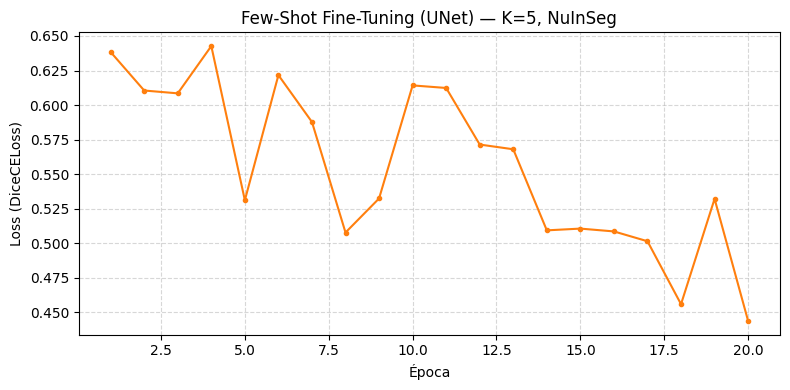


── Few-Shot: attentionunet ──
Época 1/20 — Loss: 0.5623
  → Melhor modelo salvo (Loss: 0.5623)
Época 2/20 — Loss: 0.5864
Época 3/20 — Loss: 0.5932
Época 4/20 — Loss: 0.4949
  → Melhor modelo salvo (Loss: 0.4949)
Época 5/20 — Loss: 0.5643
Época 6/20 — Loss: 0.5622
Época 7/20 — Loss: 0.5122
Época 8/20 — Loss: 0.5449
Época 9/20 — Loss: 0.5905
Época 10/20 — Loss: 0.4833
  → Melhor modelo salvo (Loss: 0.4833)
Época 11/20 — Loss: 0.5532
Época 12/20 — Loss: 0.5082
Época 13/20 — Loss: 0.5139
Época 14/20 — Loss: 0.4991
Época 15/20 — Loss: 0.4754
  → Melhor modelo salvo (Loss: 0.4754)
Época 16/20 — Loss: 0.4405
  → Melhor modelo salvo (Loss: 0.4405)
Época 17/20 — Loss: 0.5355
Época 18/20 — Loss: 0.5233
Época 19/20 — Loss: 0.5100
Época 20/20 — Loss: 0.5063


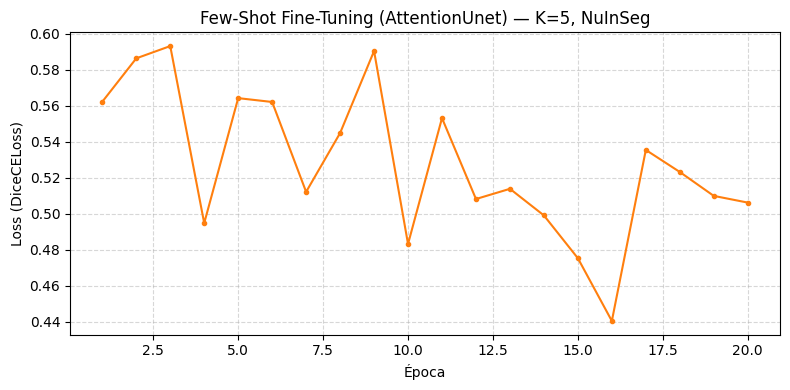


── Few-Shot: unetr ──
Época 1/20 — Loss: 0.6284
  → Melhor modelo salvo (Loss: 0.6284)
Época 2/20 — Loss: 0.6055
  → Melhor modelo salvo (Loss: 0.6055)
Época 3/20 — Loss: 0.5035
  → Melhor modelo salvo (Loss: 0.5035)
Época 4/20 — Loss: 0.4186
  → Melhor modelo salvo (Loss: 0.4186)
Época 5/20 — Loss: 0.4487
Época 6/20 — Loss: 0.5022
Época 7/20 — Loss: 0.4418
Época 8/20 — Loss: 0.3796
  → Melhor modelo salvo (Loss: 0.3796)
Época 9/20 — Loss: 0.3751
  → Melhor modelo salvo (Loss: 0.3751)
Época 10/20 — Loss: 0.3304
  → Melhor modelo salvo (Loss: 0.3304)
Época 11/20 — Loss: 0.4354
Época 12/20 — Loss: 0.3259
  → Melhor modelo salvo (Loss: 0.3259)
Época 13/20 — Loss: 0.3578
Época 14/20 — Loss: 0.3741
Época 15/20 — Loss: 0.2892
  → Melhor modelo salvo (Loss: 0.2892)
Época 16/20 — Loss: 0.3645
Época 17/20 — Loss: 0.2838
  → Melhor modelo salvo (Loss: 0.2838)
Época 18/20 — Loss: 0.3064
Época 19/20 — Loss: 0.2766
  → Melhor modelo salvo (Loss: 0.2766)
Época 20/20 — Loss: 0.2686
  → Melhor modelo

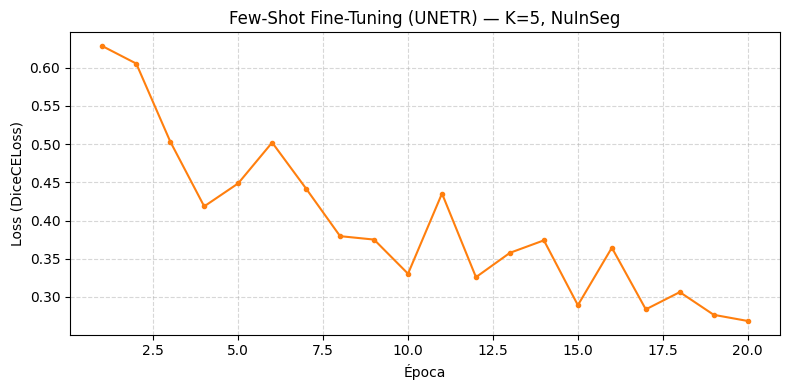

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Parâmetros
K_shots = 5
few_shot_epochs = 20

archs_few_shot = [
    ('unet', UNet(spatial_dims=2, in_channels=3, out_channels=1,
                  channels=(16, 32, 64, 128, 256), strides=(2, 2, 2, 2), num_res_units=2)),
    ('attentionunet', AttentionUnet(spatial_dims=2, in_channels=3, out_channels=1,
                                    channels=(16, 32, 64, 128, 256), strides=(2, 2, 2, 2))),
    ('unetr', UNETR(in_channels=3, out_channels=1, img_size=(256, 256), spatial_dims=2)),
]

support_set_data = random.sample(NuInSeg_train_data, k=K_shots)

print(f'Support set: {len(support_set_data)} amostras do NuInSeg.')

support_set_ds = Dataset(data=support_set_data, transform=transforms_train)
few_shot_loader = DataLoader(support_set_ds, batch_size=min(2, K_shots),
                             shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())

few_shot_loss_fn = DiceCELoss(sigmoid=True)

for arch_name, model in archs_few_shot:
    print(f'\n── Few-Shot: {arch_name} ──')
    model = model.to(device)

    weights_path = CWD / 'notebooks' / 'results' / 'models' / arch_name / f'PanNuke_{model.__class__.__name__}.pth'
    model.load_state_dict(torch.load(weights_path, map_location=device))

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
    save_path = CWD / 'notebooks' / 'results' / 'models' / arch_name / f'few_shot_k{K_shots}_NuInSeg.pth'
    save_path.parent.mkdir(parents=True, exist_ok=True)

    model.train()
    loss_history = []
    best_loss = float('inf')

    for epoch in range(few_shot_epochs):
        epoch_loss = sum(
            (lambda o=optimizer, i=b['image'].to(device), l=b['label'].to(device):
             (o.zero_grad(), loss := few_shot_loss_fn(model(i), l), loss.backward(), o.step(), loss.item())[-1])()
            for b in few_shot_loader
        ) / len(few_shot_loader)

        loss_history.append(epoch_loss)
        print(f'Época {epoch + 1}/{few_shot_epochs} — Loss: {epoch_loss:.4f}')

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(model.state_dict(), save_path)
            print(f'  → Melhor modelo salvo (Loss: {best_loss:.4f})')

    plt.figure(figsize=(8, 4))
    plt.plot(range(1, few_shot_epochs + 1), loss_history, marker='o', markersize=3, color='tab:orange')
    plt.title(f'Few-Shot Fine-Tuning ({model.__class__.__name__}) — K={K_shots}, NuInSeg')
    plt.xlabel('Época')
    plt.ylabel('Loss (DiceCELoss)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()